In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
import zipfile
import os

zip_path = "/content/YOUR_archive(2).zip"   # file name marchali

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/resume_data")

print(os.listdir("/content/resume_data"))

In [1]:
from google.colab import files
uploaded = files.upload()


Saving archive (2).zip to archive (2).zip


In [3]:
import zipfile
import os

zip_path = "/content/archive (2).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/resume_data")

print(os.listdir("/content/resume_data"))

['data', 'Resume']


In [4]:
import os

print("data folder:", os.listdir("/content/resume_data/data"))
print("Resume folder:", os.listdir("/content/resume_data/Resume"))

data folder: ['data']
Resume folder: ['Resume.csv']


In [5]:
import pandas as pd

df = pd.read_csv("/content/resume_data/Resume/Resume.csv")
df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [6]:
print(df.columns)

Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')


In [7]:
df[['Category', 'Resume_str']].head()

,Category,Resume_str
0,HR,HR ADMINISTRATOR/MARKETING ASSOCIATE\...
1,HR,"HR SPECIALIST, US HR OPERATIONS ..."
2,HR,HR DIRECTOR Summary Over 2...
3,HR,HR SPECIALIST Summary Dedica...
4,HR,HR MANAGER Skill Highlights ...


In [8]:
job_description = """
Python Machine Learning Data Analysis SQL NLP Deep Learning
"""

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [10]:
sample_df = df[['Category', 'Resume_str']].head(20).copy()
sample_df.head()

,Category,Resume_str
0,HR,HR ADMINISTRATOR/MARKETING ASSOCIATE\...
1,HR,"HR SPECIALIST, US HR OPERATIONS ..."
2,HR,HR DIRECTOR Summary Over 2...
3,HR,HR SPECIALIST Summary Dedica...
4,HR,HR MANAGER Skill Highlights ...


In [11]:
documents = sample_df['Resume_str'].tolist()
documents.append(job_description)

vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(documents)

similarity = cosine_similarity(tfidf_matrix[-1], tfidf_matrix[:-1])
scores = similarity.flatten()

sample_df["Match Score"] = scores * 100

In [12]:
ranked_df = sample_df.sort_values(by="Match Score", ascending=False)
ranked_df[['Category', 'Match Score']].head(10)

,Category,Match Score
11,HR,4.391893
8,HR,3.454295
7,HR,2.769853
17,HR,2.537145
9,HR,1.750504
19,HR,1.456725
0,HR,1.433320
16,HR,0.820818
5,HR,0.735265
10,HR,0.630361


In [13]:
sample_df = df[['Category', 'Resume_str']].sample(50, random_state=42).copy()
sample_df.head()

,Category,Resume_str
420,TEACHER,Kpandipou Koffi Summary ...
1309,DIGITAL-MEDIA,DIRECTOR OF DIGITAL TRANSFORMATION ...
2023,CONSTRUCTION,SENIOR PROJECT MANAGER Professi...
1360,CHEF,CHEF Summary Experienced ca...
2186,BANKING,OPERATIONS MANAGER Summary E...


In [14]:
documents = sample_df['Resume_str'].tolist()
documents.append(job_description)

vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(documents)

similarity = cosine_similarity(tfidf_matrix[-1], tfidf_matrix[:-1])
scores = similarity.flatten()

sample_df["Match Score"] = scores * 100

ranked_df = sample_df.sort_values(by="Match Score", ascending=False)
ranked_df[['Category', 'Match Score']].head(10)

,Category,Match Score
670,BUSINESS-DEVELOPMENT,9.166259
2079,PUBLIC-RELATIONS,8.078656
2457,AVIATION,6.236380
435,TEACHER,5.935609
1271,DIGITAL-MEDIA,5.230503
2201,BANKING,4.699942
2234,BANKING,4.294256
1341,AUTOMOBILE,3.780149
787,HEALTHCARE,3.285440
173,DESIGNER,2.186941


In [15]:
job_description = """
Python Machine Learning Deep Learning NLP SQL Data Science
Pandas NumPy TensorFlow Scikit-learn Data Analysis
"""

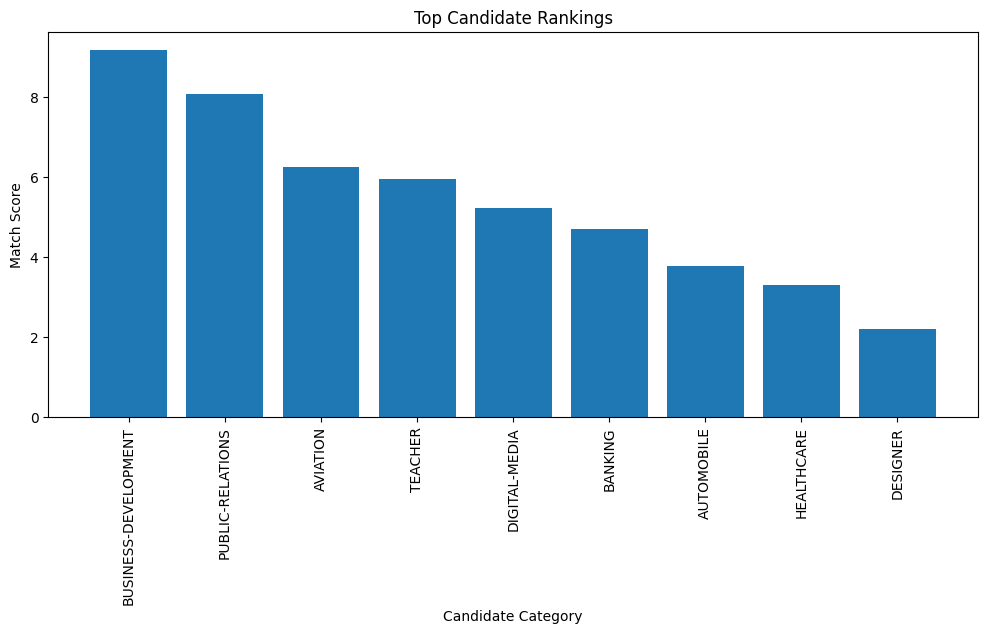

In [16]:
import matplotlib.pyplot as plt

top10 = ranked_df.head(10)

plt.figure(figsize=(12,5))
plt.bar(top10["Category"], top10["Match Score"])
plt.xticks(rotation=90)
plt.xlabel("Candidate Category")
plt.ylabel("Match Score")
plt.title("Top Candidate Rankings")
plt.show()

In [17]:
best = ranked_df.iloc[0]
print("Best Candidate Category:", best["Category"])
print("Match Score:", round(best["Match Score"], 2), "%")

Best Candidate Category: BUSINESS-DEVELOPMENT
Match Score: 9.17 %


In [18]:
required_skills = ["Python", "Machine Learning", "SQL", "NLP"]

resume_text = best["Resume_str"]

missing = []
for skill in required_skills:
    if skill.lower() not in resume_text.lower():
        missing.append(skill)

print("Missing Skills:", missing)

Missing Skills: ['Python', 'Machine Learning', 'SQL', 'NLP']


In [19]:
best = ranked_df.iloc[0]

required_skills = ["Python", "Machine Learning", "SQL", "NLP"]

resume_text = best["Resume_str"]

missing = []
for skill in required_skills:
    if skill.lower() not in resume_text.lower():
        missing.append(skill)

print("Best Candidate:", best["Category"])
print("Match Score:", round(best["Match Score"], 2), "%")
print("Missing Skills:", missing)

Best Candidate: BUSINESS-DEVELOPMENT
Match Score: 9.17 %
Missing Skills: ['Python', 'Machine Learning', 'SQL', 'NLP']
